# Triangulación multinodo — ¿con qué error ubica la red un foco?

Un solo nodo **no mide distancia** en llanura: $\Delta D/D \approx (D/H)\,\Delta\theta$ (a 5 km, 0.05° de cabeceo = 1 km de error, y el pie del fuego ni se ve sobre el monte). Dos nodos que ven el **mismo** penacho lo ubican por intersección de rumbos a ~20 m. Este notebook mide cuánto, y de qué depende: geometría ($\gamma$), calibración de acimut (domina) y ruido de píxel (despreciable).

Toda la lógica vive en `modulos/triangulacion.py` (backend, float). Lo único del nodo es $\Delta\phi=\arctan((x-c_x)/f_x)$, que viaja en la trama LoRa de 24 B.

**Pregunta:** ¿con qué error ubica la red un foco en 10×10 km con 2 y 3 nodos, y qué rompe la medición?

```bash
cd Desarrollo/Pruebas
uv run jupyter lab notebooks/9_triangulacion.ipynb
```

In [8]:
import csv
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

# Raíz del banco de pruebas = la carpeta que contiene `modulos/`.
RAIZ = next((p for p in (Path.cwd(), *Path.cwd().parents) if (p / "modulos").is_dir()), None)
if RAIZ is None:
    raise RuntimeError(f"no encuentro 'modulos/' desde {Path.cwd()}; "
                       "abrí el notebook dentro de Desarrollo/Pruebas/")
sys.path.insert(0, str(RAIZ / "modulos"))
DATOS, SALIDAS = RAIZ / "datos", RAIZ / "salidas"


def ruta_salida(nombre):
    """Ruta dentro de salidas/, creando la carpeta si hace falta."""
    SALIDAS.mkdir(parents=True, exist_ok=True)
    return SALIDAS / nombre


import triangulacion as tr

plt.rcParams.update({"figure.dpi": 110, "font.size": 8})

A, B, C = (0.0, 0.0), (5000.0, 0.0), (2500.0, 5000.0)  # nodos, metros (X=Este, Y=Norte)
F = (2500.0, 4000.0)  # foco de ejemplo

## 1 · Píxel → acimut

$\beta = \Phi_{cam} + \arctan((x-c_x)/f_x)$. Con f = 16 mm el píxel es chico (~30 arcsec); el que manda es $\sigma_{cal} \approx 0.15°$ de la calibración del acimut, no los 2 px de ruido del centroide.

In [9]:
for nombre, p, w in [("OV2640", 2.2, 1600), ("OV5640", 1.4, 2592)]:
    f = tr.focal_px(16.0, p)
    print(f"{nombre}: fx={f:.0f} px  1 px={np.degrees(1 / f) * 3600:.0f} arcsec")
fx = tr.focal_px()
print(f"ruido 2 px = {tr.sigma_ang_desde_px(2.0, fx):.4f} deg  vs  calibracion 0.15 deg")
print(f"x=900, Phi_cam=90 deg -> beta={tr.pixel_a_acimut(900, fx, 800, 90.0):.3f} deg")

OV2640: fx=7273 px  1 px=28 arcsec
OV5640: fx=11429 px  1 px=18 arcsec
ruido 2 px = 0.0158 deg  vs  calibracion 0.15 deg
x=900, Phi_cam=90 deg -> beta=90.788 deg


## 2 · Intersección: 2 rumbos (cerrada 2×2) y N rumbos (mínimos cuadrados)

Sin ruido, ambas recuperan el foco exacto. Con N ≥ 3 no hay forma cerrada: se apilan las rectas $-\cos\beta\,X + \sin\beta\,Y = c$ y se resuelve por mínimos cuadrados.

In [10]:
betas = [tr.rumbo_verdadero(*N, *F) for N in (A, B, C)]
r2 = tr.interseccion_2(*A, *B, *betas[:2])
r3 = tr.triangulacion_n([A, B, C], betas)
print(f"2 nodos: ({r2['X']:.3f}, {r2['Y']:.3f}) m  gamma={r2['gamma']:.1f} deg")
print(f"3 nodos: ({r3['X']:.3f}, {r3['Y']:.3f}) m  rms={r3['rms']:.2e} m")

2 nodos: (2500.000, 4000.000) m  gamma=64.0 deg
3 nodos: (2500.000, 4000.000) m  rms=9.60e-13 m


## 3 · Monte Carlo: mapa de error en 10×10 km con 2 y 3 nodos

Por tiro: sesgo de calibración fijo por nodo $\sim N(0, 0.15°)$ (se sortea una vez: así se modela que la calibración domina) + ruido de píxel $\sigma=2$ px por medición. El mapa guarda `mapa_error_triangulacion.png` y la tabla `exactitud_triangulacion.csv`.

/tmp/ipykernel_9278/2521503230.py:29: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


foco ejemplo: rmse=4.5 m  p50=4.1 m  p95=6.8 m  rechazo=0.00  elipse=4x3 m
mapa_error_triangulacion.png + exactitud_triangulacion.csv listos


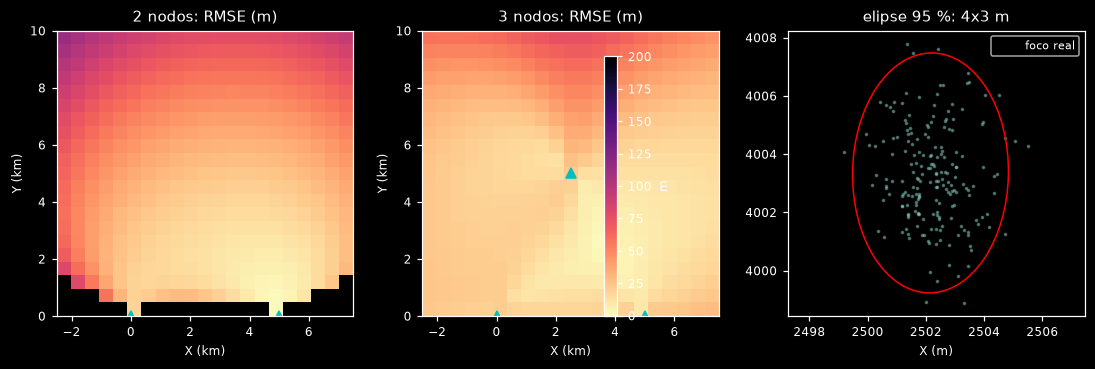

In [11]:
xs = np.linspace(-2500, 7500, 21)  # 10 km
ys = np.linspace(0, 10000, 21)   # 10 km
kw = dict(sigma_px=2.0, sigma_cal_deg=0.15, n=150, seed=11)
m2 = tr.mapa_error(xs, ys, [A, B], **kw)
m3 = tr.mapa_error(xs, ys, [A, B, C], **kw)

fig, ax = plt.subplots(1, 3, figsize=(10, 3.4))
ext = [xs[0] / 1000, xs[-1] / 1000, ys[0] / 1000, ys[-1] / 1000]
for a, m, t in zip(ax[:2], (m2, m3), ("2 nodos: RMSE (m)", "3 nodos: RMSE (m)")):
    im = a.imshow(m["rmse"], origin="lower", extent=ext, vmin=0, vmax=200,
                   aspect="auto", cmap="magma_r")
    a.set_title(t)
    a.set_xlabel("X (km)")
    a.set_ylabel("Y (km)")
    for N in ([A, B] if "2" in t else [A, B, C]):
        a.plot(N[0] / 1000, N[1] / 1000, "c^", ms=7)
fig.colorbar(im, ax=ax[:2], shrink=0.9, label="m")

# Elipses del 95 % en el foco ejemplo (2000 tiros, nube raleada para graficar)
r = tr.montecarlo_punto(F, [A, B], sigma_px=2.0, sigma_cal_deg=0.15, n=2000, seed=7)
el = tr.elipse_95(r["nube"])
a = ax[2]
a.scatter(r["nube"][::10, 0], r["nube"][::10, 1], s=2, alpha=0.4)
a.add_patch(Ellipse(el["media"], 2 * el["semieje_mayor"], 2 * el["semieje_menor"],
                      angle=el["angulo_deg"], fc="none", ec="red"))
a.plot(F[0], F[1], "k+", ms=8, label="foco real")
a.set_title(f"elipse 95 %: {el['semieje_mayor']:.0f}x{el['semieje_menor']:.0f} m")
a.set_xlabel("X (m)"); a.axis("equal"); a.legend(fontsize=7)
fig.tight_layout()
fig.savefig(ruta_salida("mapa_error_triangulacion.png"), dpi=150)

print(f"foco ejemplo: rmse={r['rmse']:.1f} m  p50={r['p50']:.1f} m  p95={r['p95']:.1f} m  "
      f"rechazo={r['rechazo']:.2f}  elipse={el['semieje_mayor']:.0f}x{el['semieje_menor']:.0f} m")
with open(ruta_salida("exactitud_triangulacion.csv"), "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["config", "rmse_med_m", "rmse_max_m", "p95_med_m", "rechazo_max"])
    for nombre, m in [("2_nodos", m2), ("3_nodos", m3)]:
        w.writerow([nombre, f"{np.nanmedian(m['rmse']):.1f}", f"{np.nanmax(m['rmse']):.1f}",
                    f"{np.nanmedian(m['p95']):.1f}", ""])
    w.writerow(["punto_F_2n", f"{r['rmse']:.1f}", "", f"{r['p95']:.1f}",
                f"{r['rechazo']:.3f}"])
print("mapa_error_triangulacion.png + exactitud_triangulacion.csv listos")

## 4 · Rechazo: cruce chico o rectas que divergen

El error escala con $1/\sin\gamma$: bajo 15° se rechaza. Y si el cruce cae detrás de una cámara (una $t<0$), las rectas divergen y también se rechaza.

In [12]:
for par in [(30.0, 32.0), (0.0, 5.0), (180.0, 135.0), (32.0, 328.0)]:
    r = tr.interseccion_2(0, 0, 1000, 0, *par)
    print(f"beta={par}: ok={r['ok']} gamma={r['gamma']:.1f} deg motivo='{r['motivo']}'")

beta=(30.0, 32.0): ok=False gamma=2.0 deg motivo='gamma 2.0 < 15.0'
beta=(0.0, 5.0): ok=False gamma=5.0 deg motivo='gamma 5.0 < 15.0'
beta=(180.0, 135.0): ok=False gamma=45.0 deg motivo='divergen (cruce detras de camara)'
beta=(32.0, 328.0): ok=True gamma=64.0 deg motivo=''


## 5 · Calibración del acimut por el sol

Sin brújula (el hierro de la torre la falsea): una foto del sol con timestamp del DS3231 alcanza. El acimut solar se calcula con NOAA simplificado (~0.01°) y se despeja $\Phi_{cam} = az_{sol} - \arctan((x_{sol}-c_x)/f_x)$.

In [13]:
az, el = tr.sol_az_elev(2025, 1, 15, 15.0, -27.45, -58.98)  # Resistencia, verano, 12:00 local
print(f"sol: az={az:.2f} deg elev={el:.2f} deg")
phi_real = 137.5
x_sol = 800 + tr.focal_px() * np.tan(np.radians(az - phi_real))
print(f"Phi recuperado: {tr.calibrar_acimut_sol(x_sol, tr.focal_px(), 800, az):.4f} deg (real {phi_real})")
# Fuentes de error: 1 px de centroide y 60 s de reloj
dphi_px = np.degrees(1 / tr.focal_px())
az2, _ = tr.sol_az_elev(2025, 1, 15, 15.0 + 1 / 60, -27.45, -58.98)
print(f"1 px de sol = {dphi_px:.4f} deg; 60 s de RTC = {abs(az2 - az):.4f} deg -> domina el centroide, no el reloj")

sol: az=70.16 deg elev=73.76 deg
Phi recuperado: 137.5000 deg (real 137.5)
1 px de sol = 0.0079 deg; 60 s de RTC = 0.3783 deg -> domina el centroide, no el reloj


## 6 · Dos focos simultáneos: intersecciones fantasma

Con 2 focos, cada nodo reporta 2 rumbos y hay 4 cruces: 2 reales + 2 fantasmas. La geometría sola no los distingue: se asocian por hora, elevación y ancho angular.

A0-B0: (2500, 4000) m  REAL
A0-B1: (7353, 11765) m  fantasma
A1-B0: (3288, 2740) m  fantasma
A1-B1: (6000, 5000) m  REAL


Text(0.5, 1.0, '2 focos: círculos reales, cruces fantasmas')

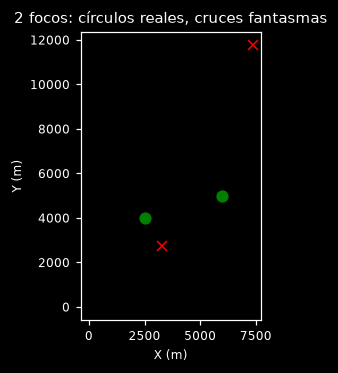

In [14]:
F1, F2 = (2500.0, 4000.0), (6000.0, 5000.0)
bA = [tr.rumbo_verdadero(*A, *f) for f in (F1, F2)]
bB = [tr.rumbo_verdadero(*B, *f) for f in (F1, F2)]
fig, a = plt.subplots(figsize=(5, 3.4))
for g in tr.intersecciones_fantasma(*A, *B, bA, bB):
    tag = "REAL" if g["i"] == g["j"] else "fantasma"
    print(f"A{g['i']}-B{g['j']}: ({g['X']:.0f}, {g['Y']:.0f}) m  {tag}")
    a.plot(g["X"], g["Y"], "go" if tag == "REAL" else "rx", ms=7)
for N in (A, B):
    a.plot(N[0], N[1], "k^", ms=8)
a.set_aspect("equal"); a.set_xlabel("X (m)"); a.set_ylabel("Y (m)")
a.set_title("2 focos: círculos reales, cruces fantasmas")

## Conclusión

Con $\gamma > 15°$ y $\sigma_{cal} = 0.15°$, la fórmula da $\sigma_{pos}\approx 21\,\text{m}$ a 5 km con $\gamma=60°$ (informe §5.2.2). El mapa y la elipse son una sola calibración (el sesgo se sortea una vez): el RMSE impreso puede quedar lejos de esos 21 m. El 3er nodo rellena las zonas de cruce chico. El ruido de píxel (2 px ≈ 0.016°) es despreciable frente a la calibración: **calibrar el acimut por el sol (~0.01–0.05°) vale más que subir resolución**. Donde sólo hay un nodo, la distancia queda como cota gruesa; y con focos simultáneos hay que asociar rumbos antes de triangular.